In [9]:
import pandas as pd
from constants import GRAY_1, GRAY_2, GRAY_3, BLUE_1
import duckdb

df = pd.read_csv("norway_new_car_sales_by_make.csv")

df

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5
...,...,...,...,...,...
4372,2017,1,Nilsson,3,0.0
4373,2017,1,Maserati,2,0.0
4374,2017,1,Ferrari,1,0.0
4375,2017,1,Smart,1,0.0


## Pick out total quantity per brand

In [17]:
df_quantity_brand = duckdb.sql("""--sql
SELECT
Make AS Brand,
SUM(Quantity) AS Quantity
FROM df
GROUP BY Brand
ORDER BY Quantity DESC
""").df().set_index("Brand")

df_quantity_brand

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0
...,...
Koenigsegg,1.0
Infiniti,1.0
Secma,1.0


## Bar charts 

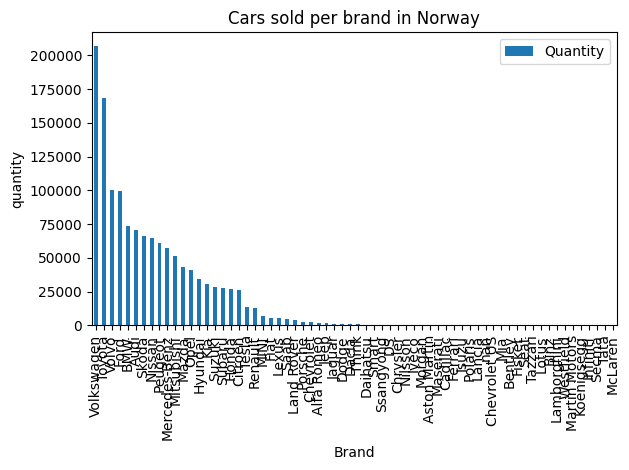

In [25]:
ax = df_quantity_brand.plot(kind="bar", y="Quantity")
ax.set(title="Cars sold per brand in Norway", ylabel="quantity")
fig = ax.get_figure()

fig.tight_layout()
fig.savefig("figures/cars_brand_sold.png", dpi=150)

## Fokus on 10 top brands

In [28]:
#df_quantity_brand.head(10)

df_top_10_brands = df_quantity_brand.iloc[:10]
df_top_10_brands

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0
Audi,70475.0
Skoda,66007.0
Nissan,64535.0
Peugeot,61033.0


<Axes: title={'center': 'Top cars sold in Norway'}, xlabel='Brand', ylabel='Number cars'>

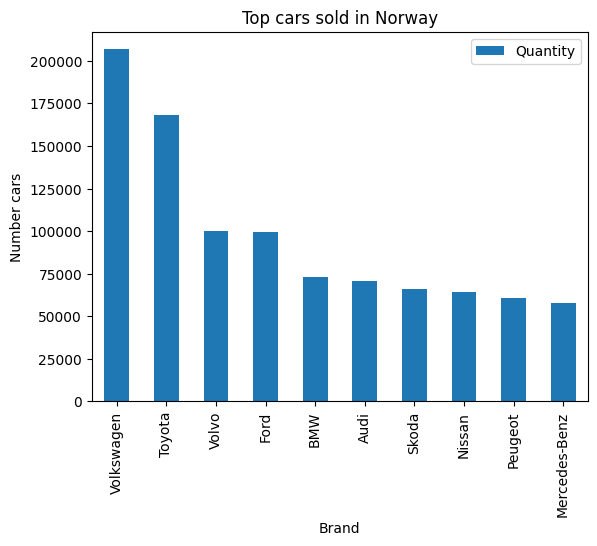

In [ ]:
df_top_10_brands.plot(kind="bar", title="Top cars sold in Norway", ylabel="Number cars")

## Data Storytelling
- attention
- contrast
- descriptive title
- proximity with annotation 
- remove clutter
- horizontal bar (hbar)
- clear xlabel and ylabel
- percentage insted of absolute value

In [37]:
# to get percentage
total_quantity = df_top_10_brands["Quantity"].sum() # summera alla

df_percentage = df_top_10_brands["Quantity"]/total_quantity*100 # räkna ut procent
df_percentage

Brand
Volkswagen       21.362948
Toyota           17.384109
Volvo            10.330281
Ford             10.307127
BMW               7.578420
Audi              7.284855
Skoda             6.823007
Nissan            6.670850
Peugeot           6.308855
Mercedes-Benz     5.949548
Name: Quantity, dtype: float64

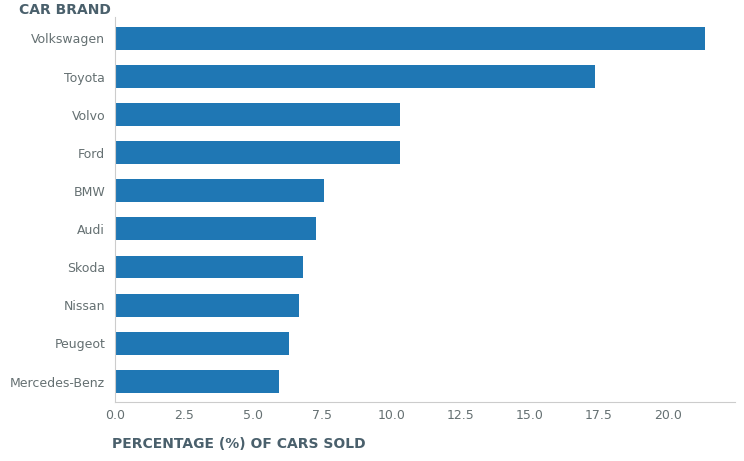

In [81]:
ax = df_percentage.plot(kind="barh", figsize=(8, 5), width=0.6)

ax.spines[["top", "right"]].set_visible(False) # ta bort topp och höger linjer
ax.spines[["left", "bottom"]].set_color(GRAY_1) # tona ned färgerna

ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0, pad=5) # tona ned färger i botten och sidan och snygga till
ax.tick_params(axis="y", pad=7)

ax.set_xlabel("PERCENTAGE (%) OF CARS SOLD", color=GRAY_3, fontweight="bold")
ax.set_ylabel("CAR BRAND", color=GRAY_3, fontweight="bold", rotation=0)

ax.yaxis.set_label_coords(-.08, 1) # placera ylabel
ax.xaxis.set_label_coords(0.2, -0.09) # placera xlabel

ax.invert_yaxis()